In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
file_path = Path("/Users/elina/Downloads/Restaurant Recommendation Web App Feedback Survey (Responses).xlsx")

df = pd.read_excel(file_path)

df.head()

,Timestamp,Our web app was easy to use.,The AI-generated summary helped me quickly understand each restaurant.,The review evidence made the AI recommendation more trustworthy.,The image analysis helped me understand the restaurant atmosphere and space.,The score breakdown helped me understand why one restaurant ranked higher than another.,"Overall, our restaurant recommendation web app was useful for making a dining decision.","Compared with Google Maps or Yelp, our web app made it easier to understand the main strengths and weaknesses of each restaurant.","Compared with manually reading many reviews, our web app’s summary saved me time.","Compared with ChatGPT or other AI products, our web app felt more grounded and useful because it used real restaurant reviews, photos, and a score breakdown.",Which part of our web app was the most helpful?,Which tool would you prefer to use for finding restaurants?,"Please describe your overall experience using our restaurant recommendation web app. What did you like, and what areas do you think could be improved?"
0,2026-05-03 12:35:10,5,5,2,5,1,5,2,5,5,"Input filters, such as ZIP code, cuisine, part...",Our AI restaurant recommendation web app,"Good summary, clear reasons, but could be faster."
1,2026-05-03 12:35:10,4,4,5,4,5,4,1,5,5,Score breakdown,Our AI restaurant recommendation web app,Easy to use and helpful. More filters would be...
2,2026-05-03 12:35:10,5,3,4,5,5,5,4,5,3,Top-3 ranking,Our AI restaurant recommendation web app,"Overall, I thought the app was useful. I liked..."
3,2026-05-03 22:46:26,5,2,3,1,5,4,5,5,5,Top-3 ranking,Our AI restaurant recommendation web app,The web app was easy to understand. The score ...
4,2026-05-04 13:54:55,5,1,5,3,5,1,1,1,5,Review evidence,Our AI restaurant recommendation web app,"Overall, I thought the app was useful. The sum..."


In [3]:
df_clean = df.copy()

df_clean.columns = df_clean.columns.str.strip()

df_clean.columns

Index(['Timestamp', 'Our web app was easy to use.',
       'The AI-generated summary helped me quickly understand each restaurant.',
       'The review evidence made the AI recommendation more trustworthy.',
       'The image analysis helped me understand the restaurant atmosphere and space.',
       'The score breakdown helped me understand why one restaurant ranked higher than another.',
       'Overall, our restaurant recommendation web app was useful for making a dining decision.',
       'Compared with Google Maps or Yelp, our web app made it easier to understand the main strengths and weaknesses of each restaurant.',
       'Compared with manually reading many reviews, our web app’s summary saved me time.',
       'Compared with ChatGPT or other AI products, our web app felt more grounded and useful because it used real restaurant reviews, photos, and a score breakdown.',
       'Which part of our web app was the most helpful?',
       'Which tool would you prefer to use for find

In [4]:
rename_map = {
    "Our web app was easy to use.": "Easy to Use",
    "The AI-generated summary helped me quickly understand each restaurant.": "AI Summary Helpful",
    "The review evidence made the AI recommendation more trustworthy.": "Review Evidence Trust",
    "The image analysis helped me understand the restaurant atmosphere and space.": "Image Analysis Helpful",
    "The score breakdown helped me understand why one restaurant ranked higher than another.": "Score Breakdown Helpful",
    "Overall, our restaurant recommendation web app was useful for making a dining decision.": "Overall Useful"
}

df_clean = df_clean.rename(columns=rename_map)

df_clean.head()

,Timestamp,Easy to Use,AI Summary Helpful,Review Evidence Trust,Image Analysis Helpful,Score Breakdown Helpful,Overall Useful,"Compared with Google Maps or Yelp, our web app made it easier to understand the main strengths and weaknesses of each restaurant.","Compared with manually reading many reviews, our web app’s summary saved me time.","Compared with ChatGPT or other AI products, our web app felt more grounded and useful because it used real restaurant reviews, photos, and a score breakdown.",Which part of our web app was the most helpful?,Which tool would you prefer to use for finding restaurants?,"Please describe your overall experience using our restaurant recommendation web app. What did you like, and what areas do you think could be improved?"
0,2026-05-03 12:35:10,5,5,2,5,1,5,2,5,5,"Input filters, such as ZIP code, cuisine, part...",Our AI restaurant recommendation web app,"Good summary, clear reasons, but could be faster."
1,2026-05-03 12:35:10,4,4,5,4,5,4,1,5,5,Score breakdown,Our AI restaurant recommendation web app,Easy to use and helpful. More filters would be...
2,2026-05-03 12:35:10,5,3,4,5,5,5,4,5,3,Top-3 ranking,Our AI restaurant recommendation web app,"Overall, I thought the app was useful. I liked..."
3,2026-05-03 22:46:26,5,2,3,1,5,4,5,5,5,Top-3 ranking,Our AI restaurant recommendation web app,The web app was easy to understand. The score ...
4,2026-05-04 13:54:55,5,1,5,3,5,1,1,1,5,Review evidence,Our AI restaurant recommendation web app,"Overall, I thought the app was useful. The sum..."


In [5]:
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()

numeric_cols

['Easy to Use',
 'AI Summary Helpful',
 'Review Evidence Trust',
 'Image Analysis Helpful',
 'Score Breakdown Helpful',
 'Overall Useful',
 'Compared with Google Maps or Yelp, our web app made it easier to understand the main strengths and weaknesses of each restaurant.',
 'Compared with manually reading many reviews, our web app’s summary saved me time.',
 'Compared with ChatGPT or other AI products, our web app felt more grounded and useful because it used real restaurant reviews, photos, and a score breakdown.']

In [6]:
rating_cols = [
    "Easy to Use",
    "AI Summary Helpful",
    "Review Evidence Trust",
    "Image Analysis Helpful",
    "Score Breakdown Helpful",
    "Overall Useful"
]

In [7]:
summary = df_clean[rating_cols].agg(["mean", "std", "count"]).T
summary = summary.rename(columns={
    "mean": "Average Score",
    "std": "Standard Deviation",
    "count": "Number of Responses"
})

summary

,Average Score,Standard Deviation,Number of Responses
Easy to Use,3.793103,1.311787,145.0
AI Summary Helpful,3.917241,1.277495,145.0
Review Evidence Trust,4.055172,1.305859,145.0
Image Analysis Helpful,3.903448,1.298098,145.0
Score Breakdown Helpful,4.048276,1.345419,145.0
Overall Useful,3.951724,1.376040,145.0


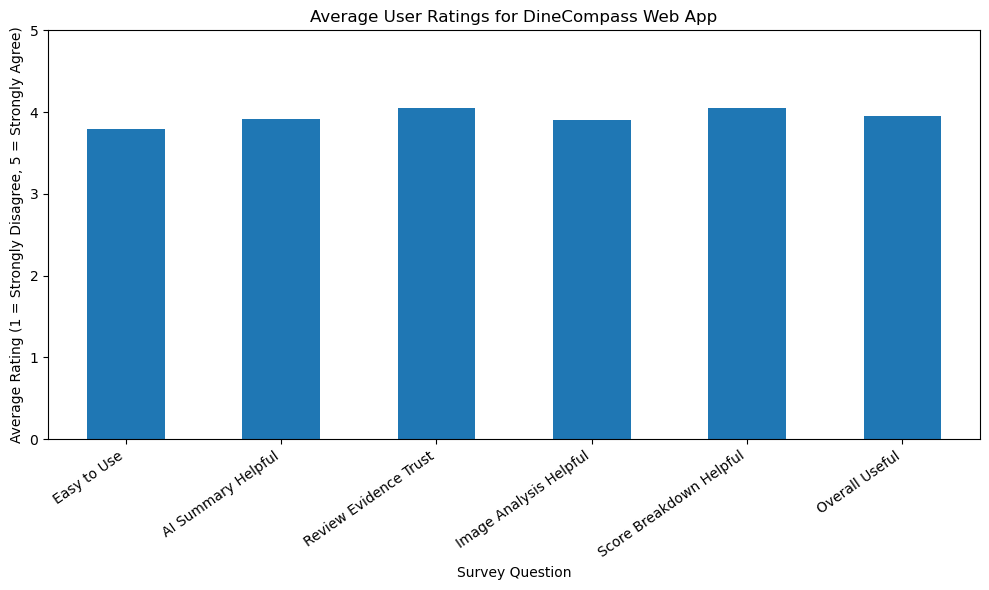

In [8]:
plt.figure(figsize=(10, 6))

summary["Average Score"].plot(kind="bar")

plt.title("Average User Ratings for DineCompass Web App")
plt.xlabel("Survey Question")
plt.ylabel("Average Rating (1 = Strongly Disagree, 5 = Strongly Agree)")
plt.ylim(0, 5)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.show()

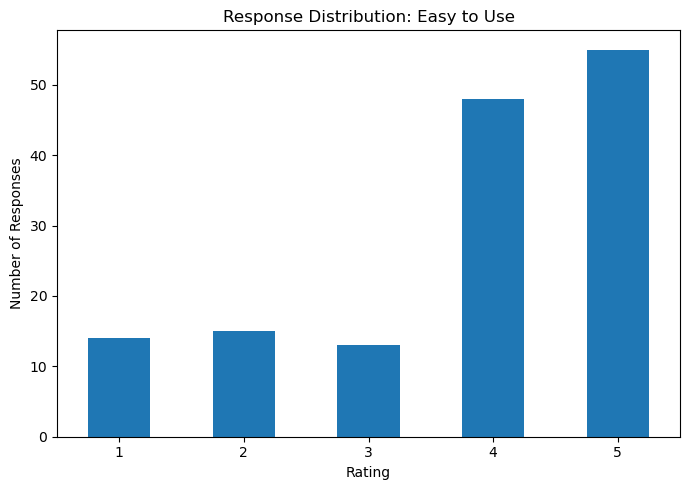

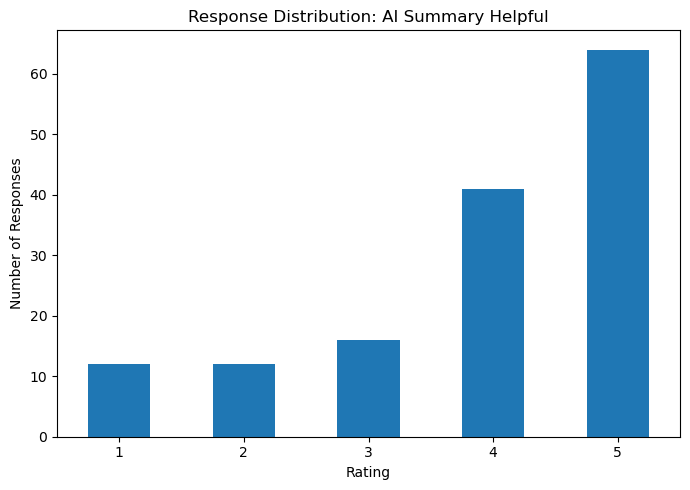

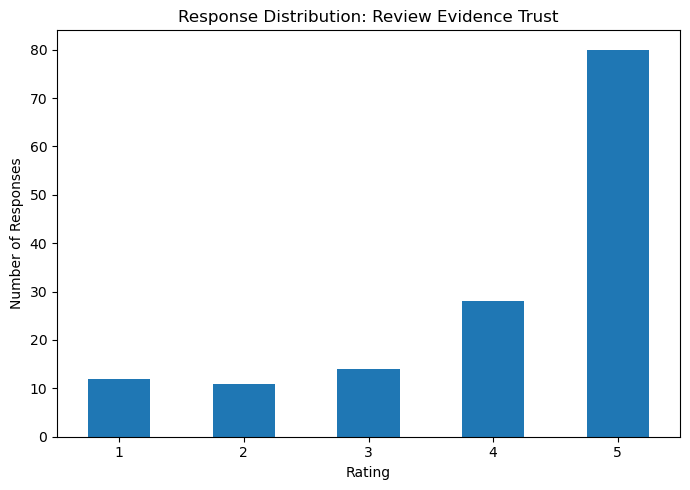

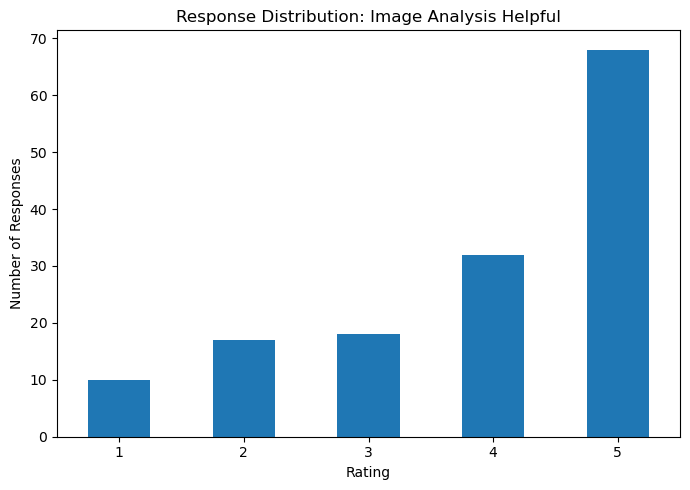

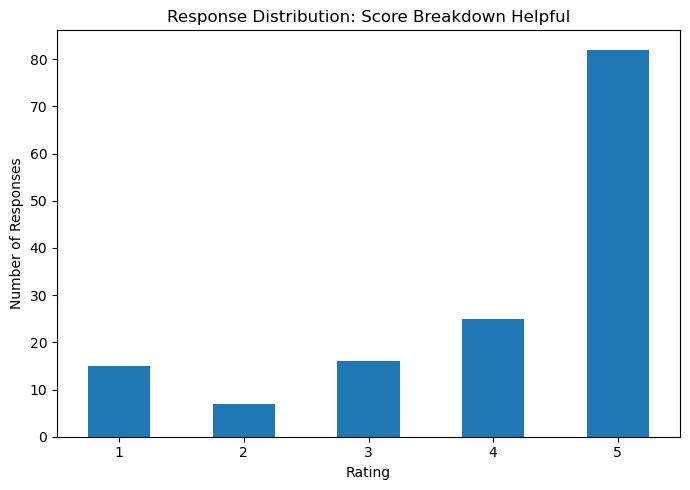

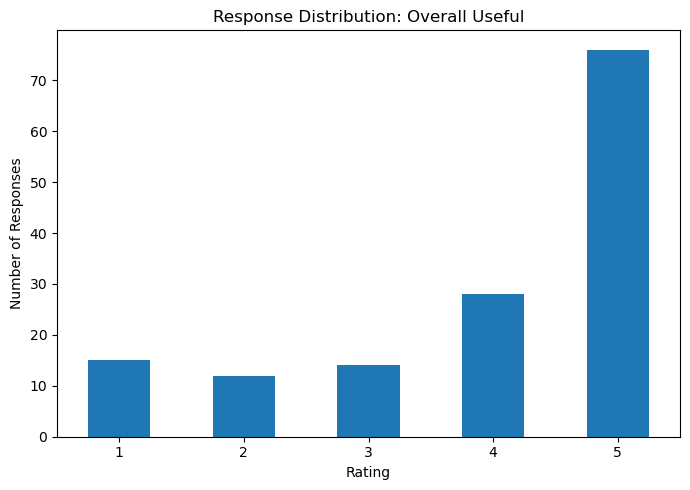

In [9]:
for col in rating_cols:
    counts = df_clean[col].value_counts().sort_index()

    plt.figure(figsize=(7, 5))
    counts.plot(kind="bar")

    plt.title(f"Response Distribution: {col}")
    plt.xlabel("Rating")
    plt.ylabel("Number of Responses")
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.show()

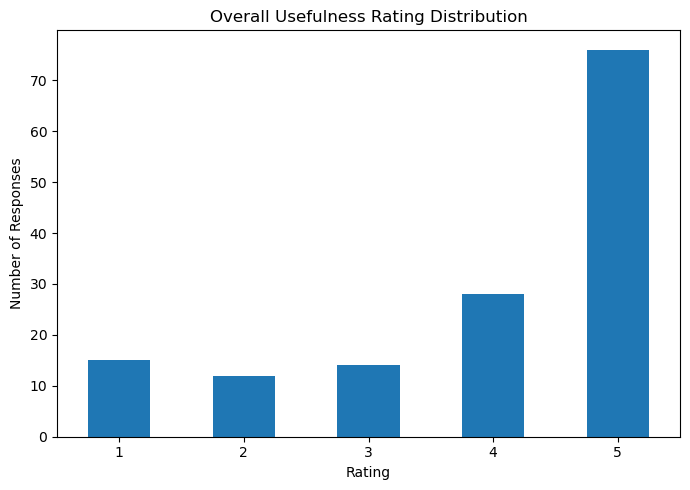

In [10]:
overall_col = "Overall Useful"

counts = df_clean[overall_col].value_counts().sort_index()

plt.figure(figsize=(7, 5))
counts.plot(kind="bar")

plt.title("Overall Usefulness Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Responses")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

<Figure size 1100x600 with 0 Axes>

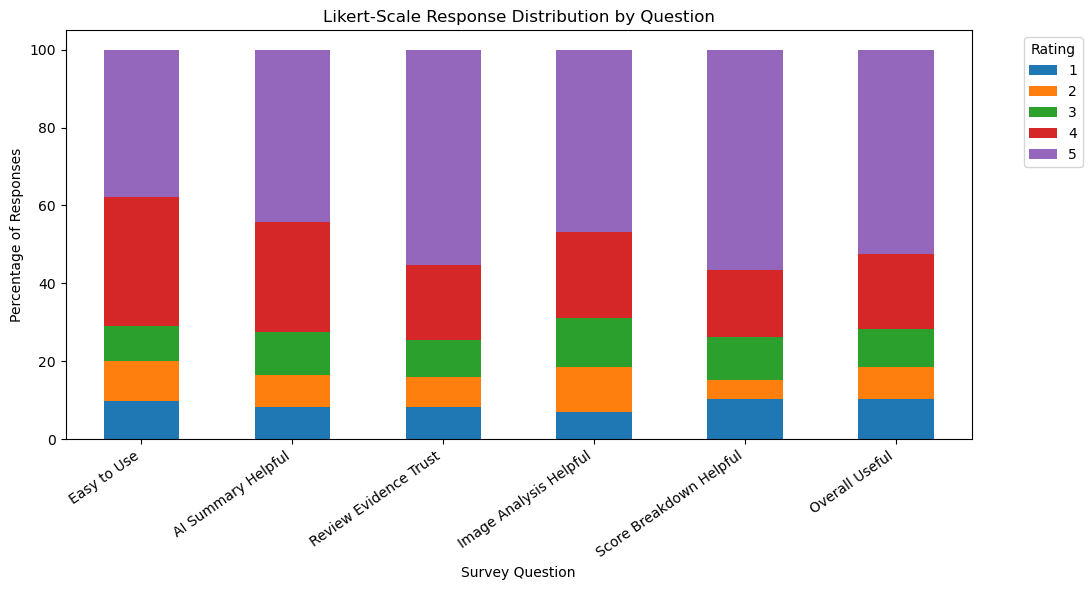

In [11]:
likert_percent = {}

for col in rating_cols:
    percent = df_clean[col].value_counts(normalize=True).sort_index() * 100
    likert_percent[col] = percent

likert_percent_df = pd.DataFrame(likert_percent).T
likert_percent_df = likert_percent_df.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)

likert_percent_df
plt.figure(figsize=(11, 6))

likert_percent_df.plot(kind="bar", stacked=True, figsize=(11, 6))

plt.title("Likert-Scale Response Distribution by Question")
plt.xlabel("Survey Question")
plt.ylabel("Percentage of Responses")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

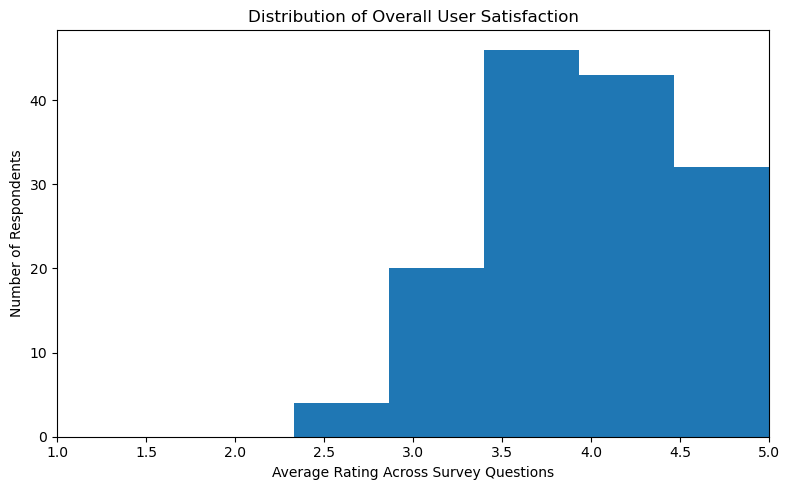

In [13]:
df_clean["Average Satisfaction"] = df_clean[rating_cols].mean(axis=1)

df_clean[["Average Satisfaction"]].head()
plt.figure(figsize=(8, 5))

df_clean["Average Satisfaction"].plot(kind="hist", bins=5)

plt.title("Distribution of Overall User Satisfaction")
plt.xlabel("Average Rating Across Survey Questions")
plt.ylabel("Number of Respondents")
plt.xlim(1, 5)
plt.tight_layout()

plt.show()